In [57]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import UNX_to_UTC
from helper import find_closest_index_dt

import math
from scipy.interpolate import interp1d
from numpy.linalg import LinAlgError

In [3]:
from detection_helper import *

In [5]:
times_arr, freq_arr, data_arr = return_arr('2023-08-19', '2023-08-20')

23-Dec-25 22:58:59: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
23-Dec-25 22:59:00: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
23-Dec-25 22:59:00: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
23-Dec-25 22:59:00: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
23-Dec-25 22:59:00: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
23-Dec-25 22:59:01: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
23-Dec-25 22:59:01: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
23-Dec-25 22:59:01: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


In [109]:
freq_log, freq_log_exp, data_arr_log = convert_data_log(freq_arr, data_arr)

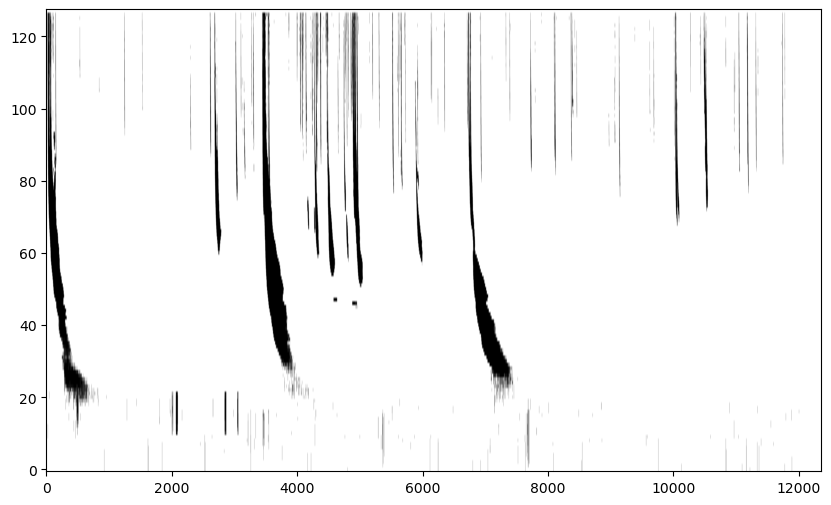

In [19]:
bmap_row_mean = bmap_row_mean_loop_new(times_arr=times_arr, full_data=data_arr_log, min_duration=1)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

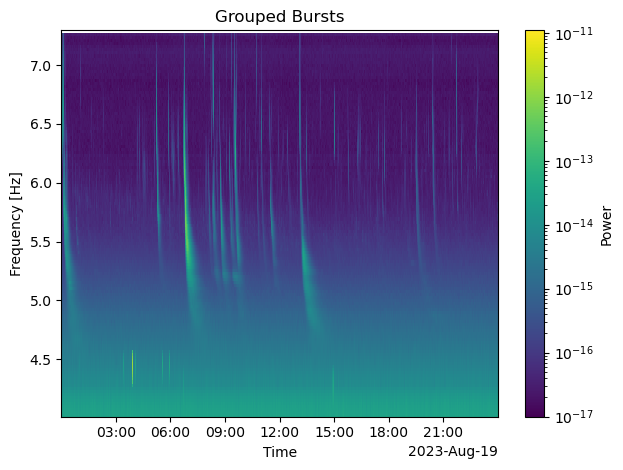

In [17]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr_log.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [251]:
def hough_angle(freq_change, freq_log, time_duration, times_arr):
    # times in second
    # times_arr in UTC
    target_freq = max(freq_log) - freq_change
    target_freq_index = 0
    while target_freq_index < len(freq_log) and freq_log[target_freq_index] < target_freq:
        target_freq_index += 1
    target_freq_index_reverse = len(freq_log) - target_freq_index

    times_arr_UNX = UTC_to_UNX(times_arr)
    target_time = times_arr_UNX[1] + time_duration
    target_time_index = 0
    while target_time_index < len(times_arr_UNX) and times_arr_UNX[target_time_index] < target_time:
        target_time_index += 1

    angle_rad = math.atan2(-target_freq_index_reverse, target_time_index)
    angle_deg = math.degrees(angle_rad) + 90

    return target_freq_index_reverse, target_time_index, angle_deg

freq_change_mean=14718120.082815735
duration_mean=2699.503105590062

target_freq_index_reverse, target_time_index, angle_deg = hough_angle(freq_change_mean, freq_log, duration_mean, times_arr)
target_freq_index_reverse, target_time_index, angle_deg

(25, 388, 86.31335782704286)

In [253]:
theta=np.deg2rad(np.linspace(angle_deg-10, angle_deg+10, 120))

time_diff = 1000
freq_diff = 100000000

lines = hough_detect(bmap_row_mean, data_arr_log, threshold=10, line_gap=50, line_length=60, theta=theta)
line_sets, line_sets_actual = line_grouping_new(times_arr, freq_log, lines, time_diff, freq_diff)
line_sets_actual

[(('2023-08-19 00:04:53.434980+00:00', 18071703.899664175),
  ('2023-08-19 00:06:10.330740+00:00', 34390.436779852265)),
 (('2023-08-19 06:45:12.868773+00:00', 18071703.899664175),
  ('2023-08-19 06:46:57.726451+00:00', 463156.0418319953)),
 (('2023-08-19 08:18:18.295657+00:00', 18071703.899664175),
  ('2023-08-19 08:19:35.191173+00:00', 521265.1388009401)),
 (('2023-08-19 08:43:28.248216+00:00', 18071703.899664175),
  ('2023-08-19 08:45:06.115658+00:00', 521265.1388009401)),
 (('2023-08-19 09:18:25.404940+00:00', 18071703.899664175),
  ('2023-08-19 09:20:24.243821+00:00', 344666.41374003445)),
 (('2023-08-19 11:30:11.685839+00:00', 7447559.763082143),
  ('2023-08-19 11:32:10.524719+00:00', 28803.19539681081)),
 (('2023-08-19 13:27:31.142668+00:00', 15135685.013465311),
  ('2023-08-19 13:29:22.991068+00:00', 241771.3988388319))]

In [290]:
line_sets

[((47, 158), (112, 157)),
 ((44, 3578), (118, 3564)),
 ((62, 4338), (122, 4338)),
 ((60, 4518), (120, 4506)),
 ((20, 5000), (82, 4991)),
 ((34, 5938), (116, 5924)),
 ((26, 6944), (100, 6937))]

<Figure size 1000x600 with 0 Axes>

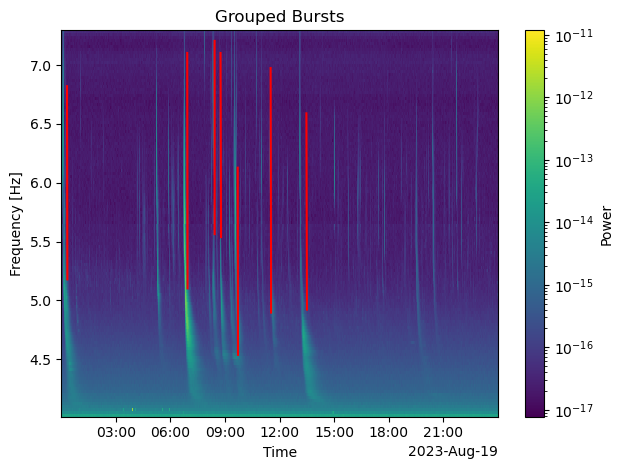

In [159]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0], times_arr[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [478]:
import numpy as np
import numpy.linalg as LA
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter
import numpy.linalg as LA

def PJcurvature(x,y):
    """
    input  : the coordinate of the three point
    output : the curvature and norm direction
    refer to https://github.com/peijin94/PJCurvature for detail
    """
    t_a = LA.norm([x[1]-x[0],y[1]-y[0]])
    t_b = LA.norm([x[2]-x[1],y[2]-y[1]])

    M = np.array([
        [1, -t_a, t_a**2],
        [1, 0,    0     ],
        [1,  t_b, t_b**2]])

    a = np.matmul(LA.pinv(M),x)
    b = np.matmul(LA.pinv(M),y)

    kappa = 2*(a[2]*b[1]-b[2]*a[1])/(a[1]**2.+b[1]**2.)**(1.5)
    return kappa, [b[1],-a[1]]/np.sqrt(a[1]**2.+b[1]**2.)


def ACBone(img,x,y,x0,y0,n_iter = 200,d_step=0.2,alpha=25,beta=6000,y_gap=90.,blur_sigma=2.5):
        # print((y0[0]),(y0[1]))
        N=int(abs(y0[1]-y0[0])/y_gap)
        N=300
        yy = np.linspace((y0[0]),(y0[1]), 300)
        # print(int(abs(y0[1]-y0[0])/y_gap))
        # print(yy)
        xx = np.linspace((x0[0]),(x0[1]), len(yy))# +  np.random.normal(0, 0.1, len(yy))
        # print("\n[INIT]")
        # print("x0=", x0, "y0=", y0)
        # print("y_gap=", y_gap, "dy=", float(abs(y0[1]-y0[0])))
        # print("N=", len(xx))
        # print("xx head/tail:", xx[:3], xx[-3:])
        # print("yy head/tail:", yy[:3], yy[-3:])
        # print("finite xx?", np.isfinite(xx).all(), "finite yy?", np.isfinite(yy).all())

        # blurred = gaussian_filter(img, sigma=blur_sigma)
        blurred = img

        Grad_x = interp2d(x, y, np.gradient(img,axis=1)/(np.max(np.gradient(img,axis=1))), kind='quintic')
        Grad_y = interp2d(x, y, np.gradient(img,axis=0)/(np.max(np.gradient(img,axis=0))), kind='quintic')


        Grad_x_blur = interp2d(x, y, np.gradient(blurred,axis=1)/(np.max(np.gradient(blurred,axis=1))), kind='quintic')
        Grad_y_blur = interp2d(x, y, np.gradient(blurred,axis=0)/(np.max(np.gradient(blurred,axis=0))), kind='quintic')

        xx_new = xx
        yy_new = yy

        idx_img=0
        # print(n_iter)
        for step in range(n_iter):
            kappa_arr = np.zeros(len(xx))
            norm_arr  = np.zeros([len(xx),2])
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # print('xx')
            # print(xx[1:-1])
            # print(xx)
            for idx,val in enumerate(xx[1:-1]):
                # print('idx')
                # print(idx)
                # print('val')
                # print(val)
                ytmp = yy_new[idx:idx+3]
                # print('ytmp')
                # print(ytmp)
                xtmp = xx_new[idx:idx+3]
                # print('xtmp')
                # print(xtmp)
                try: 
                    kappa,norm_l = PJcurvature(xtmp,ytmp)
                    kappa_arr[idx+1] = kappa
                    norm_arr[idx+1,:] = norm_l
                except LinAlgError:
                    pass
                
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # plt.plot(xx_new,kappa_arr)
            # plt.show()
            # plt.plot(xx_new,norm_arr)
            # plt.show()
            
            f_x = beta* kappa_arr*norm_arr[:,0]
            f_x[-1] = -f_x[-2]
            f_x[0] = -f_x[1]
            if step>n_iter/3.5 :
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)
            else:
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)

            #print(alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
            #                for i in np.arange(len(xx_new))])[:,0])
            #yy_new = yy_new+ d_step/1000* (alpha * np.array([Grad_y(xx_new[i],yy_new[i])
            #                                            for i in np.arange(len(xx_new))])[:,0])

        img_xy = interp2d(x, y, img, kind='quintic')
        flux = np.array([img_xy(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0]

        return xx_new,yy_new,flux

In [274]:
img = data_arr_log.T[:-1]
x = UTC_to_UNX(times_arr)
y = freq_log[:-1]

In [298]:
line_sets[1]

((44, 3578), (118, 3564))

In [308]:
line_sets[1][0]

(44, 3578)

In [310]:
line_sets[1][0][0]

44

In [440]:
x0 = (x[line_sets[1][1][1]], x[line_sets[1][0][1]])
y0 = (y[line_sets[1][1][0]], y[line_sets[1][0][0]])

In [480]:
xx, yy, flux = ACBone(img, x, y, x0, y0, n_iter = 50)
xx, yy, flux

(array([1.69242812e+09, 1.69242812e+09, 1.69242812e+09, 1.69242812e+09,
        1.69242812e+09, 1.69242812e+09, 1.69242812e+09, 1.69242812e+09,
        1.69242812e+09, 1.69242812e+09, 1.69242812e+09, 1.69242812e+09,
        1.69242812e+09, 1.69242813e+09, 1.69242813e+09, 1.69242813e+09,
        1.69242813e+09, 1.69242813e+09, 1.69242813e+09, 1.69242813e+09,
        1.69242813e+09, 1.69242813e+09, 1.69242813e+09, 1.69242813e+09,
        1.69242813e+09, 1.69242813e+09, 1.69242813e+09, 1.69242813e+09,
        1.69242813e+09, 1.69242813e+09, 1.69242813e+09, 1.69242813e+09,
        1.69242813e+09, 1.69242813e+09, 1.69242813e+09, 1.69242813e+09,
        1.69242813e+09, 1.69242813e+09, 1.69242813e+09, 1.69242813e+09,
        1.69242813e+09, 1.69242813e+09, 1.69242813e+09, 1.69242814e+09,
        1.69242814e+09, 1.69242814e+09, 1.69242814e+09, 1.69242814e+09,
        1.69242814e+09, 1.69242814e+09, 1.69242814e+09, 1.69242814e+09,
        1.69242814e+09, 1.69242814e+09, 1.69242814e+09, 1.692428

<Figure size 1000x600 with 0 Axes>

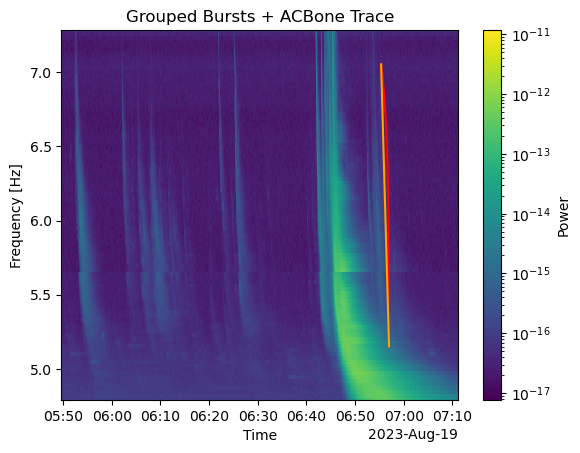

In [468]:
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()

p = ax.pcolormesh(
    times_arr,
    freq_log_exp,
    data_arr.T,
    norm=LogNorm(),
    shading='auto'
)

plt.colorbar(p, ax=ax, label='Power')

ax.plot(UNX_to_UTC(xx), np.log10(yy), 'r-', color='red')
ax.plot(UNX_to_UTC(x0), np.log10(y0), 'r-', color='orange')

ax.set_xlim(times_arr[3000], times_arr[3700])
ax.set_ylim(freq_log_exp[30], freq_log_exp[-1])

ax.set_xlabel("Time")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Grouped Bursts + ACBone Trace")

# plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

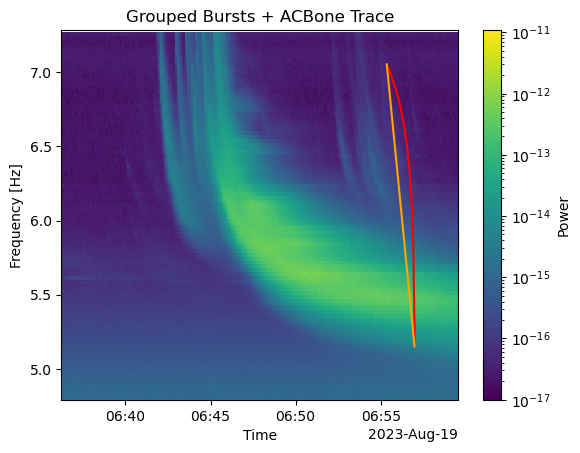

In [470]:
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()

p = ax.pcolormesh(
    times_arr,
    freq_log_exp,
    data_arr_log.T,
    norm=LogNorm(),
    shading='auto'
)

plt.colorbar(p, ax=ax, label='Power')

ax.plot(UNX_to_UTC(xx), np.log10(yy), 'r-', color='red')
ax.plot(UNX_to_UTC(x0), np.log10(y0), 'r-', color='orange')

ax.set_xlim(times_arr[3400], times_arr[3600])
ax.set_ylim(freq_log_exp[30], freq_log_exp[-1])

ax.set_xlabel("Time")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Grouped Bursts + ACBone Trace")

# plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

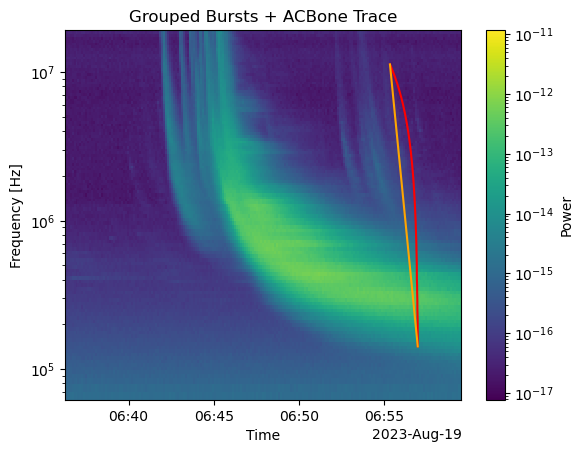

In [418]:
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()

p = ax.pcolormesh(
    times_arr,
    freq_arr,
    data_arr.T,
    norm=LogNorm(),
    shading='auto'
)

plt.colorbar(p, ax=ax, label='Power')

ax.plot(UNX_to_UTC(xx), yy, 'r-', color='red')
ax.plot(UNX_to_UTC(x0), y0, 'r-', color='orange')

ax.set_xlim(times_arr[3400], times_arr[3600])
ax.set_ylim(freq_log[30], freq_log[-1])

ax.set_xlabel("Time")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Grouped Bursts + ACBone Trace")
ax.set_yscale('log')

# plt.tight_layout()
plt.show()

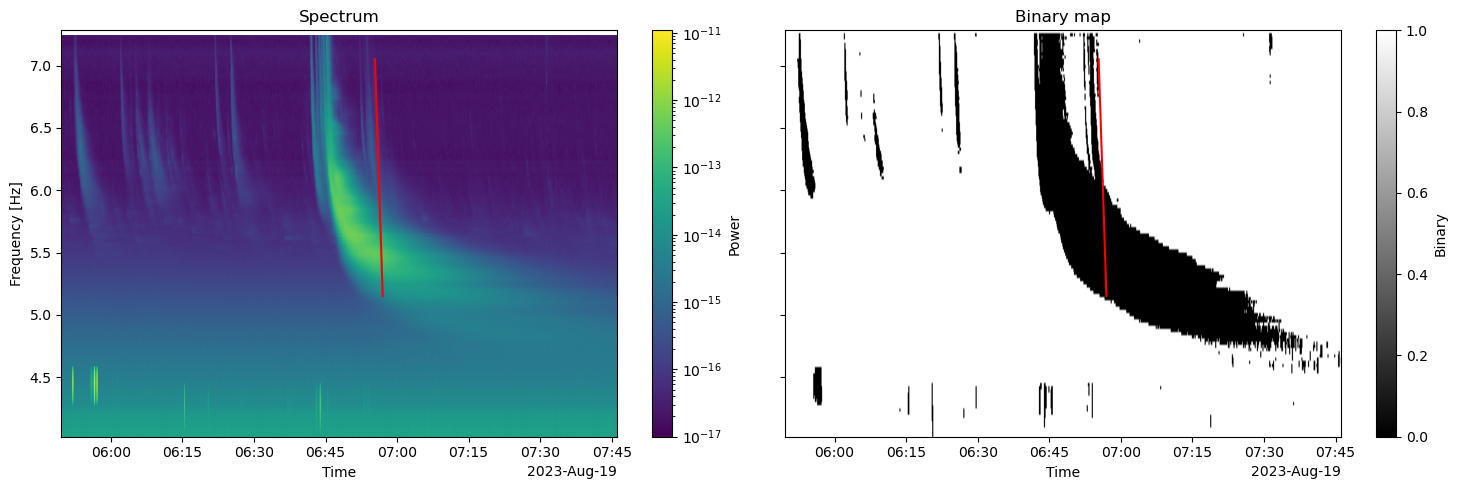

In [318]:
extent = [times_arr[0], times_arr[-1], freq_log_exp[0], freq_log_exp[-1],]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

fig1 = ax1.imshow(
    data_arr_log.T,
    origin="lower",
    aspect="auto",
    extent=extent,
    norm=LogNorm()
)
fig.colorbar(fig1, ax=ax1, label="Power")
for (x0_each, y0_each), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0_each], times_arr[y1]
    f0, f1 = freq_log_exp[x0_each], freq_log_exp[x1]
    ax1.plot([t0, t1], [f0, f1], color='red')
ax1.set_xlim(times_arr[3000], times_arr[4000])
ax1.set_title("Spectrum")
ax1.set_xlabel("Time")
ax1.set_ylabel("Frequency [Hz]")

fig2 = ax2.imshow(
    1-bmap_row_mean.T,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="gray"
)
fig.colorbar(fig2, ax=ax2, label="Binary")
for (x0_each, y0_each), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0_each], times_arr[y1]
    f0, f1 = freq_log_exp[x0_each], freq_log_exp[x1]
    ax2.plot([t0, t1], [f0, f1], color='red')
ax2.set_xlim(times_arr[3000], times_arr[4000])
ax2.set_title("Binary map")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

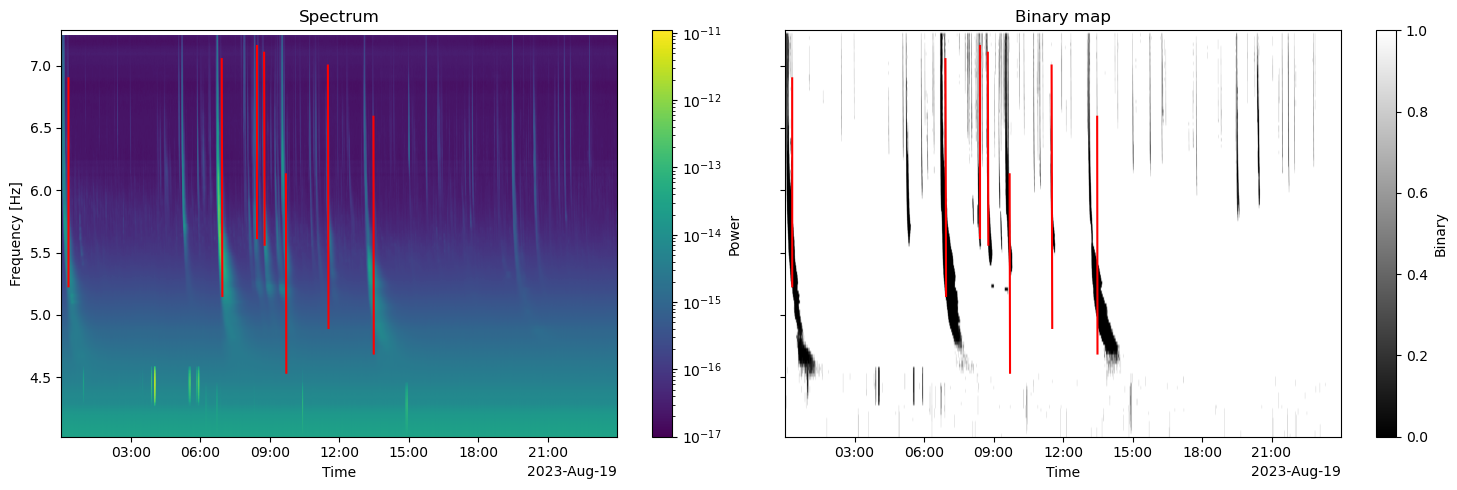

In [350]:
extent = [times_arr[0], times_arr[-1], freq_log_exp[0], freq_log_exp[-1],]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

fig1 = ax1.imshow(
    data_arr_log.T,
    origin="lower",
    aspect="auto",
    extent=extent,
    norm=LogNorm()
)
fig.colorbar(fig1, ax=ax1, label="Power")
for (x0_each, y0_each), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0_each], times_arr[y1]
    f0, f1 = freq_log_exp[x0_each], freq_log_exp[x1]
    ax1.plot([t0, t1], [f0, f1], color='red')
# ax1.set_xlim(times_arr[3000], times_arr[4000])
ax1.set_title("Spectrum")
ax1.set_xlabel("Time")
ax1.set_ylabel("Frequency [Hz]")

fig2 = ax2.imshow(
    1-bmap_row_mean.T,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="gray"
)
fig.colorbar(fig2, ax=ax2, label="Binary")
for (x0_each, y0_each), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0_each], times_arr[y1]
    f0, f1 = freq_log_exp[x0_each], freq_log_exp[x1]
    ax2.plot([t0, t1], [f0, f1], color='red')
# ax2.set_xlim(times_arr[3000], times_arr[4000])
ax2.set_title("Binary map")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

In [362]:
data_arr.shape

(12359, 128)